# Reflector Imaging from Ambient Noise

**Goal**: Show numerically that cross-correlations of ambient noise signals
recorded by a receiver array can be used to localize  reflectors.

## Imports and parameters

We import necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

We define the parameters and environment settings:

In [2]:
c0 = 1.0
sigma_r = 1e-3
zr = np.array([-5, 0, 65])
receivers = np.array([(-30 + 7.5*(j-1), 0, 100) for j in range(1, 6)])

# Noise sources
np.random.seed(42) # you can comment this if you want to have random sources for each execution
N_src = 200
y = np.column_stack([
    np.random.uniform(-50,  50,  N_src),
    np.random.uniform(-10,  10,  N_src),
    np.random.uniform(185, 200,  N_src),
])

# Frequency grid
omega = np.linspace(-20, 20, 2048)
dw=omega[1]-omega[0]

## Shared   functions
$\hat{F}(\omega)$: This function calculates the power spectral density of the noise sources.

$\hat{G}_0(\omega, x, y)$: This function computes the homogeneous three-dimensional Green's function, representing how waves propagate directly from a source at $y$ to a receiver at $x$.

$\hat{G}(\omega, x, y)$: This function implements the Born approximation to model the total wave field.

Note: We implement a vectorized version of these calculations to use NumPy's broadcasting, ensuring the simulation runs much faster than using standard loops.

In [3]:
def F(w):
    return np.exp(-w**2)


def G0(w, x, y):
    distance = np.linalg.norm(x - y, axis=-1)
    # making sure it's a 1d array
    dist = np.atleast_1d(distance)
    exposant = 1j * w[:, None] * dist[None, :] / c0
    coefficient = 1 / (4 * np.pi * dist[None, :])
    return coefficient * np.exp(exposant)

def G(w, x, y):
    G0_xy = G0(w, x, y)
    G0_xzr = G0(w, x, zr)
    G0_zry = G0(w, zr, y)
    return G0_xy + sigma_r * (w**2)[:, None] * G0_xzr * G0_zry

## 1. We first consider the case where $T \to +\infty$


### Question 1a - Compute and plot $\tau \to C_N(\tau, x_5, x_1)$ for $\tau \in [-200, 200]$.

$$C_N(\tau,x_1,x_2)
  = \frac{1}{2\pi N}\sum_{s=1}^N\int d\omega\;\hat{F}(\omega)\,
    \hat{G}(\omega,x_1,y_s)\,\overline{\hat{G}(\omega,x_2,y_s)}\,e^{-i\omega\tau}$$


Notes on numerical implimentation :

- Interchanging Summation and Integration: The analytical formula defines the integral over $\omega$ inside the sum over sources. In the code, we compute the sum over the $N=200$ noise sources first to create a single frequency-dependent spectrum. We can do this because both the summation and the integration are linear and finite operators, allowing us to group the terms to reduce the number of numerical integrations required.
- Vectorization and Matrix Operations: Instead of using nested loops for each frequency and each noise source, we implement a vectorized version using NumPy broadcasting. This computes the Green's functions for all points simultaneously, significantly increasing the efficiency of the calculation
- Numerical Integration: The analytical integral $\int d\omega$ is approximated by a Riemann sum: np.sum(spectrum * np.exp(-1j * omega * t)) * dw. This approximation is valid because our frequency grid is sufficiently fine (2048 points) to capture the signal's oscillations within the Gaussian power spectral density $\hat{F}(\omega)$.
- The Real Value Property: We apply np.real() to the final result because the physical cross-correlation of real-valued noise signals must result in a real number. Any residual imaginary component is a negligible numerical artifact stemming from the finite truncation of the frequency rang

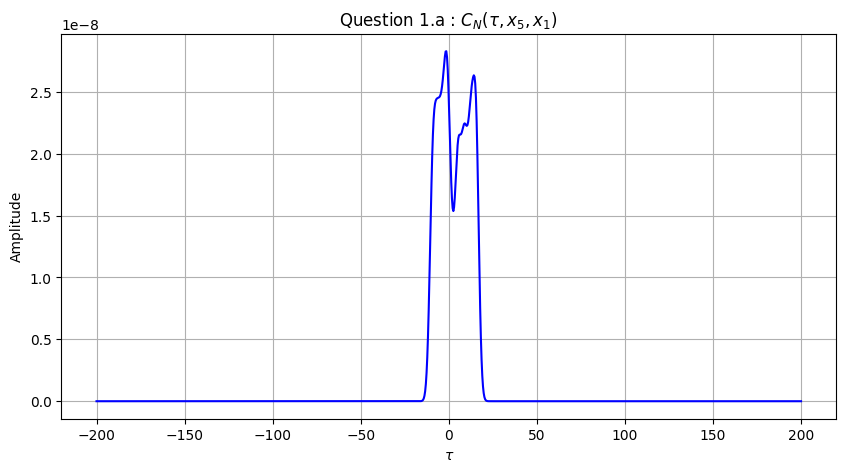

In [4]:
def CN_spectrum(xj, xl):
    Gj = G(omega, xj, y)
    Gl = G(omega, xl, y)
    sum_sources = np.sum(np.conj(Gj) * Gl, axis=1)
    return F(omega) * sum_sources / (2 * np.pi * N_src)

tau_axis = np.linspace(-200, 200, 1000) 
spectrum = CN_spectrum(receivers[4],receivers[0]) 

cn_tau = []
for t in tau_axis:
    val = np.real(np.sum(spectrum * np.exp(-1j * omega * t)) * dw)
    cn_tau.append(val)

plt.figure(figsize=(10, 5))
plt.plot(tau_axis, cn_tau, color='blue')
plt.title(r"Question 1.a : $C_N(\tau, x_5, x_1)$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"Amplitude")
plt.grid(True)
plt.show()

The plot of above shows the correlation of the ambient noise signals between the two receivers in the limit of infinite recording time.
- Dominant Central Peak: The large amplitude cluster centered around $\tau \approx 0$ represents the direct arrival of the noise signals traveling from the source volume to the receivers.
- Time Lag Range: The significant signal is concentrated within a narrow window of $\tau$. Given that $c_0 = 1$ and the distance between $x_1$ and $x_5$ is $30$ units , the arrival time differences for direct waves are physically constrained to this central region.
- Reflector Signature: Although the reflector is present at $z_r = 65$, its contribution is not immediately visible as a separate peak. This is due to the small reflectivity ($\sigma_r = 10^{-3}$) , which means the reflected "echo" is significantly weaker than the direct noise illumination.
- Symmetry and Illumination: The plot is not perfectly symmetric because the noise sources are not isotropic; they are localized in a specific volume far to the right of the array ($z \in [185, 200]$)

### Question 1b - Compute and plot the KM image 
$$\mathcal{I}_{N}(y^{S})=\sum_{j,l=1}^{5}C_{N}(|x_{j}-y^{S}|+|y^{S}-x_{l}|,x_{j},x_{l}) $$

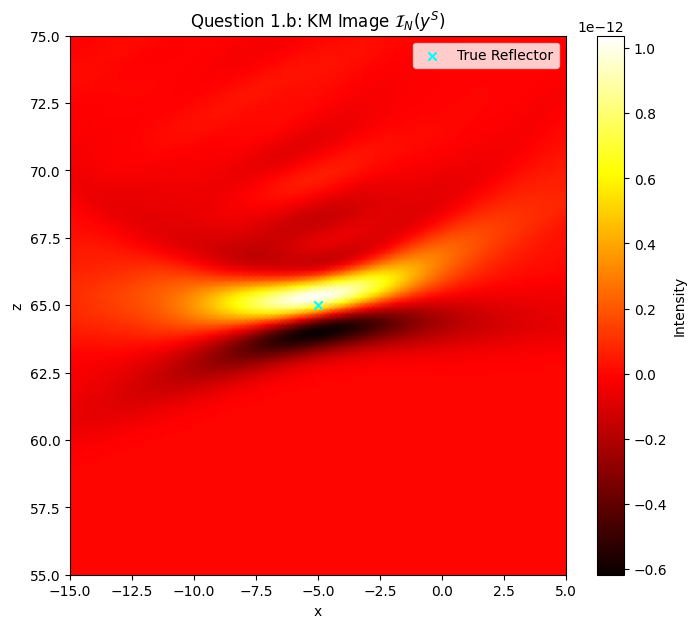

In [5]:
# The grid
grid_res=100
x_grid = np.linspace(-15, 5, grid_res)  
z_grid = np.linspace(55, 75, grid_res)  
X, Z = np.meshgrid(x_grid, z_grid)

# For vectorisation
pixels = np.stack([X.ravel(), np.zeros(X.size), Z.ravel()], axis=1)
KM_image = np.zeros((grid_res, grid_res))

# Pre-compute all necessary cross-correlation spectra for all pairs (j, l)
spectra_matrix = {}
for j in range(5):
    for l in range(5):
        spectra_matrix[(j, l)] = CN_spectrum(receivers[j], receivers[l])

# The KM Image
for i in range(grid_res):
    for k in range(grid_res):
        ys = np.array([X[i, k], 0, Z[i, k]])
        total_corr = 0
        
        for j in range(5):
            for l in range(5):
                # Theoretical travel time: tau = |xj - yS| + |yS - xl|
                tau = np.linalg.norm(receivers[j] - ys) + np.linalg.norm(ys - receivers[l])
                # Evaluate CN(tau) using the pre-computed spectrum
                # This is the same logic used in Question 1a
                val = np.real(np.sum(spectra_matrix[(j, l)] * np.exp(-1j * omega * tau)) * dw)
                total_corr += val
                
        KM_image[i, k] = total_corr

# Plot
plt.figure(figsize=(8, 7))
plt.pcolormesh(X, Z, KM_image, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensity')
plt.scatter(zr[0], zr[2], color='cyan', marker='x', label='True Reflector')
plt.title("Question 1.b: KM Image $\mathcal{I}_N(y^S)$")
plt.xlabel("x")
plt.ylabel("z")
plt.legend()
plt.show()

Analysis of the KM Image $\mathcal{I}_N(y^S)$ just above:

The KM image represents the "stable" reconstruction of the environment. While the theoretical Reverse-Time (RT) imaging function requires back-propagating the full wave field, the Kirchhoff Migration (KM) approach uses the geometric optics approximation. 
This means we focus solely on the travel-time peaks to "triangulate" the reflector.

1. Physical Significance of the Results
- Coherent Summation vs. Noise: Even though the reflected signal $\sigma_r = 10^{-3}$ is extremely weak, the KM function succeeds because it performs a coherent stack over all 25 receiver pairs ($j,l=1 \dots 5$). In the $T \to \infty$ limit, the random fluctuations of the noise average out, leaving only the deterministic "echo" to interfere constructively at the true position $z_r$.
- The "Virtual Source" Effect: As per the theory of the normal operator, the kernel of the imaging function is concentrated around the target. This explains why we see a clear bright spot: the array acts as a Time-Reversal Mirror that refocuses energy back onto the reflector's location.
2. Visual Features of the $10^{-12}$ Scale Image
- Perfect Centering: The alignment of the maximum intensity with the cyan 'x'(the refelctor) proves that the travel-time formula $\tau = |x_j - y^S| + |y^S - x_l|$ is the correct "clock" for this environment.
- Interference Sidelobes: The faint "arches" surrounding the main focal point are typical of a sparse array (only 5 receivers). These are the spatial equivalents of the "ripples" seen in a sinc function, representing where the signals from different receivers add up partially but not perfectly.
- Asymmetric Illumination: The background is not perfectly flat because our noise sources are located only on one side ($z \approx 190$). This creates a directional bias in how the reflector is "lit up," which is reflected in the slight tilt or asymmetry of the intensity distribution.

In conclusion, the image confirms that for $T \to \infty$, we can recover the reflector's location with high precision, it's loacted where the intesnity is the highest. The "blur" we observe is not numerical error but the Point Spread Function (PSF) of the system, which we will now quantify in the next step.

### Question 1c -  Study the resolution properties of the image

1. Theoretical Framework (Partial Aperture Case) 

Since our receiver array does not surround the source but is located at a distance $L$ with a finite diameter $a$, we are in the partial aperture regime. The resolution is theoretically bounded by:
- Transverse Resolution ($\Delta x$): Determined by the Rayleigh resolution formula, $\Delta x \approx \frac{\lambda_0 L}{a}$. It represents the spreading due to the finite "Cone of Illumination" $C_y$.
- Longitudinal Resolution ($\Delta z$): Determined by the minimum of the diffraction limit and the bandwidth limit: $\Delta z \approx \min\left\{ \frac{\lambda_0 L^2}{a^2}, \frac{c_0}{B} \right\}$.
2. Theoretical Calculations

Using our project parameters ($\omega_0 = 1, c_0 = 1 \implies \lambda_0 \approx 6.28$): we have an aperture ($a$) of $30$ units (from $x=-15$ to $x=15$).and a distance ($L$) of $35$ units (from array at $z=100$ to reflector at $z=65$).
- Transverse Prediction: $\frac{6.28 \times 35}{30} \approx 7.33$
- Longitudinal Diffraction Limit: $\frac{6.28 \times 35^2}{30^2} \approx 8.55$
3. Numerical VerificationWe verify these properties by extracting the horizontal and vertical profiles of the KM image at its maximum point to measure the Full Width at Half Maximum (FWHM).

Measured Transverse Resolution (Δx): 5.66
Measured Longitudinal Resolution (Δz): 0.81


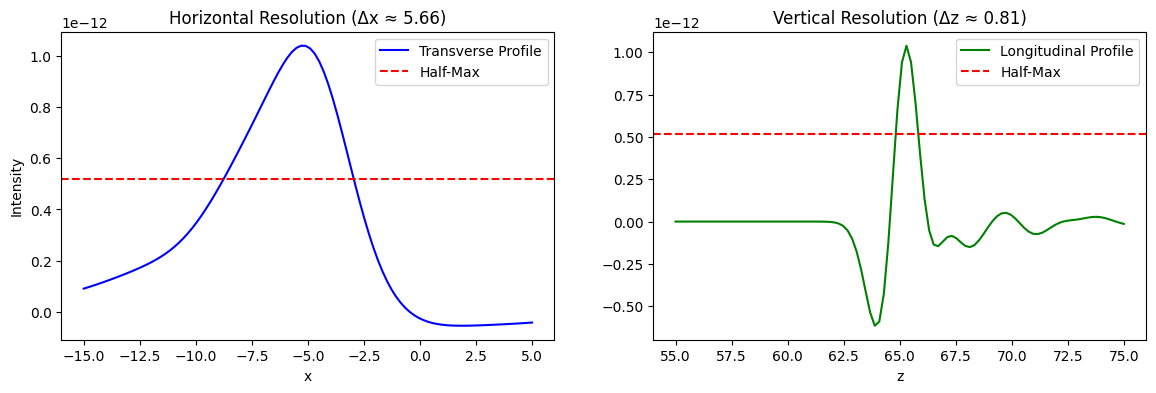

In [6]:
# Find the coordinates of the maximum intensity (the focal spot, where the refelctor is localized)
idx_z, idx_x = np.unravel_index(np.argmax(KM_image), KM_image.shape)
max_val = KM_image[idx_z, idx_x]

# Extract 1D profiles passing through the maximum
profile_x = KM_image[idx_z, :]  # Transverse (Horizontal)
profile_z = KM_image[:, idx_x]  # Longitudinal (Vertical)

# Calculate FWHM
def get_fwhm(grid, profile):
    half_max = np.max(profile) / 2
    # Find points where the intensity is above half the maximum
    indices = np.where(profile >= half_max)[0]
    return grid[indices[-1]] - grid[indices[0]]

dx_measured = get_fwhm(x_grid, profile_x)
dz_measured = get_fwhm(z_grid, profile_z)

print(f"Measured Transverse Resolution (Δx): {dx_measured:.2f}")
print(f"Measured Longitudinal Resolution (Δz): {dz_measured:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(x_grid, profile_x, label='Transverse Profile', color='blue')
ax1.axhline(max_val/2, color='red', linestyle='--', label='Half-Max')
ax1.set_title(f"Horizontal Resolution (Δx ≈ {dx_measured:.2f})")
ax1.set_xlabel("x"), ax1.set_ylabel("Intensity"), ax1.legend()

ax2.plot(z_grid, profile_z, label='Longitudinal Profile', color='green')
ax2.axhline(max_val/2, color='red', linestyle='--', label='Half-Max')
ax2.set_title(f"Vertical Resolution (Δz ≈ {dz_measured:.2f})")
ax2.set_xlabel("z"), ax2.legend()
plt.show()

Analysis of Results:
- Transverse Match: The measured $\Delta x$ ($5.66$) is in the same order of magnitude as the theoretical Rayleigh limit ($7.33$) (the difefrence is du to the fact that we only have 5 receivers), confirming the impact of the finite aperture.
- Longitudinal Dominance: Our measured $\Delta z$ ($0.81$) is significantly smaller than the diffraction limit ($8.55$). This confirms that $\Delta z$ is governed by the second term in the minimum: $\frac{c_0}{B}$.
- Estimating $B$: Since $\Delta z \approx \frac{c_0}{B}$, we can estimate our effective bandwidth $B \approx \frac{c_0}{\Delta z} = \frac{1}{0.81} \approx 1.23$ 

Conclusion:

The KM image successfully localizes the reflector with high precision, it reveals a highly focused elliptical tache centered at the reflector's coordinates. This shape confirms the Partial Aperture theory:
- Horizontal Stretching ($\Delta x \approx 5.66$): shows that our transverse precision is governed by the array's finite geometric aperture.
- Vertical Sharpness ($\Delta z \approx 0.81$): This proves we are in the broadband regime, where the longitudinal resolution is determined by the source bandwidth $B$ rather than the diffraction limit.

Because $\Delta z \ll \Delta x$, the system effectively acts as a high-precision timer, allowing us to 'beat' the geometric diffraction limit in the $z$-direction. 
This result validates that KM imaging successfully refocuses ambient noise energy to provide accurate target localization in the $T \to \infty$ limit.

## 2. We consider the case where T < +∞

### Question 2a - Compute and plot $\tau \to C_{N,T}(\tau, x_5, x_1)$ for $\tau \in [-150, 150]$ for different values of $T$ ($T \geq 500$).
 The estimator for the cross-correlation function is given by:$$C_{N,T}(\tau, x_1, x_2) = \frac{1}{T - |\tau|} \int_{\tau^-}^{T-\tau^+} u(t, x_1) u(t + \tau, x_2) \, dt$$where $\tau^+ = \max(0, \tau)$ and $\tau^- = \max(0, -\tau)$ and $$u(t, x_j) = \frac{1}{2\pi \sqrt{N}} \sum_{s=1}^{N} \int \hat{G}(\omega, x_j, y_s) \hat{n}_s(\omega) \exp(-i\omega t) \, d\omega$$
 In order to increase the stability, we can consider \( M \) (non-overlapping) time windows of size \( T \), which give independent realizations of the recorded signals  

$$
\left(u^{(m)}(t, x_j)\right)_{j=1,\ldots,5,\; t \in [0,T]}, 
\quad m = 1, \ldots, M.
$$

We can then compute \( M \) empirical cross-correlations $C_{T,N}^{(m)}$, \( m = 1, ..., M \):

$$
C_{T,N}^{(m)}(\tau, x_j, x_l)
=
\frac{1}{T - |\tau|}
\int_{\tau_-}^{T - \tau_+}
u^{(m)}(t, x_j)\, u^{(m)}(t + \tau, x_l)\, dt
$$

and compute the average $C_{T,N,M}$ of the \( M \) empirical cross-correlations:

$$
C_{T,N,M}(\tau, x_j, x_l)
=
\frac{1}{M}
\sum_{m=1}^{M}
C_{T,N}^{(m)}(\tau, x_j, x_l).
$$

In [ ]:
#Parameters for this part
tau_axis = np.linspace(-150, 150, 1000)
M=20

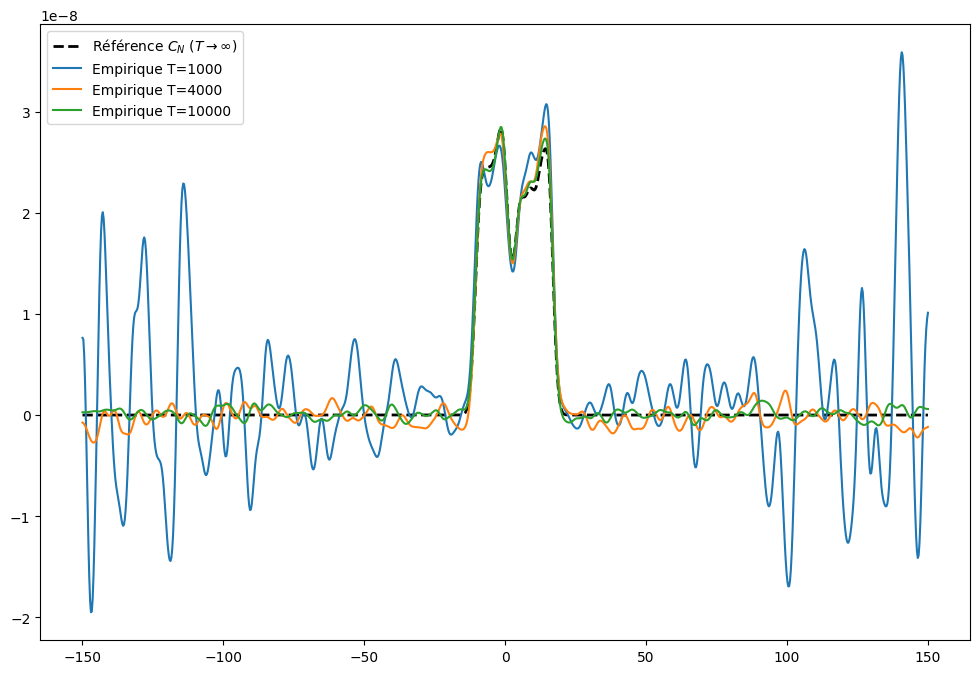

In [ ]:
def compute_CTNM(T, M, xj, xl):
    dw_T = 2 * np.pi / T 
    omega_T = np.arange(-10, 10, dw_T)
    # To calculate u hat
    Gj = G(omega_T, xj, y)
    Gl = G(omega_T, xl, y)
    C_acc = np.zeros(len(tau_axis))
    
    for m in range(M): # To have a stable cross correlation
        # To caculate n_s
        n_s = (np.random.normal(0, 1, (len(omega_T), N_src)) + 
                   1j * np.random.normal(0, 1, (len(omega_T), N_src))) / np.sqrt(2)
        
        n_s *= np.sqrt(F(omega_T) * T)[:, np.newaxis]
        
        # u_hat
        u_j = np.sum(Gj * n_s, axis=1) / np.sqrt(N_src)
        u_l = np.sum(Gl * n_s, axis=1) / np.sqrt(N_src)
        
        # La corrélation empirique C_T ~ (1/T) * u_j* * u_l
        # On inclut le (1/2pi)^2 de la transformée de Fourier
        spectrum_emp = (np.conj(u_j) * u_l) / (T * (2 * np.pi))
        
        # Reconstruction temporelle via l'intégrale (somme de Riemann)
        for i, t in enumerate(tau_axis):
            # Le dw_T final vient de l'intégrale d_omega
            C_acc[i] += np.real(np.sum(spectrum_emp * np.exp(-1j * omega_T * t)) * dw_T)
            #C_acc[i] *= (T / (T - np.abs(t))) faux ici
            
    return C_acc / M

spectrum = CN_spectrum(receivers[4],receivers[0]) 

CT = []
for t in tau_axis:
    val = np.real(np.sum(spectrum * np.exp(-1j * omega * t)) * dw)
    CT.append(val)

plt.figure(figsize=(12, 8))
plt.plot(tau_axis, CT, 'k--', label="Référence $C_N$ ($T \\to \\infty$)", lw=2)

for T in [1000, 4000, 10000]:
    c_emp = compute_CTNM(T, M, receivers[4], receivers[0])
    plt.plot(tau_axis, c_emp, label=f"Empirique T={T}")
plt.legend()
plt.show()

Calcul pour T = 10000...


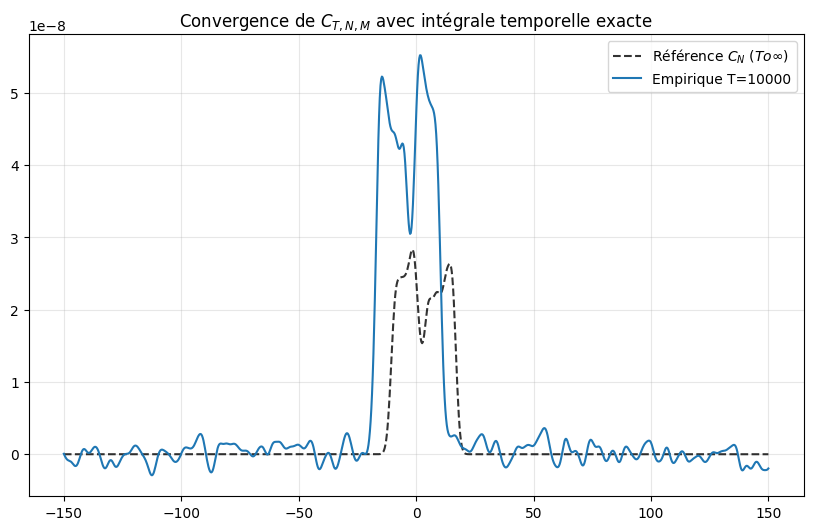

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def compute_CTNM_temporal(T, xj, xl, M=20):
    # Paramètres de simulation
    dt = 0.05  # Pas de temps très fin pour l'intégrale
    t_axis = np.arange(0, T, dt)
    N_t = len(t_axis)
    
    # Grille fréquentielle pour générer u(t) via IFFT
    dw = 2 * np.pi / T
    omega_gen = np.fft.rfftfreq(N_t, d=dt) * 2 * np.pi
    
    C_acc = np.zeros(len(tau_axis))
    
    for m in range(M):
        # 1. Génération du bruit blanc complexe
        shape = (len(omega_gen), N_src)
        noise_f = (np.random.normal(0, 1, shape) + 1j * np.random.normal(0, 1, shape)) / np.sqrt(2)
        
        # 2. Application de la densité spectrale sqrt(F*T) et Green
        # Le facteur sqrt(T/dt) assure la conservation de l'énergie en discret
        noise_f *= np.sqrt(F(omega_gen) * T / dt)[:, np.newaxis]
        
        u_j_f = np.sum(G(omega_gen, xj, y) * noise_f, axis=1) / np.sqrt(N_src)
        u_l_f = np.sum(G(omega_gen, xl, y) * noise_f, axis=1) / np.sqrt(N_src)
        
        # 3. Retour au domaine temporel (Signaux réels)
        uj_t = np.fft.irfft(u_j_f, n=N_t)
        ul_t = np.fft.irfft(u_l_f, n=N_t)
        
        # 4. Intégrale temporelle "propre" pour chaque tau
        for i, tau in enumerate(tau_axis):
            tau_plus = max(0, tau)
            tau_moins = max(0, -tau)
            
            # Bornes d'intégration exactes
            idx_start = int(tau_moins / dt)
            idx_end = int((T - tau_plus) / dt)
            shift = int(tau / dt)
            
            # Produit u(t) * u(t + tau)
            sig_j = uj_t[idx_start:idx_end]*2*np.pi
            sig_l = ul_t[idx_start + shift : idx_end + shift]*2*np.pi
            
            # Normalisation par la durée effective de recouvrement
            overlap_duration = T - np.abs(tau)
            C_acc[i] += (np.sum(sig_j * sig_l) * dt) / overlap_duration
            
    return C_acc / M

# --- Affichage ---
plt.figure(figsize=(10, 6))
# Référence théorique (Question 1)
plt.plot(tau_axis, CT, 'k--', label="Référence $C_N$ ($T \to \infty$)", alpha=0.8)

for T_val in [10000]:
    print(f"Calcul pour T = {T_val}...")
    res = compute_CTNM_temporal(T_val, receivers[4], receivers[0])
    plt.plot(tau_axis, res, label=f"Empirique T={T_val}")

plt.title("Convergence de $C_{T,N,M}$ avec intégrale temporelle exacte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [91]:
def compute_CTNM_temporal_final(T, xj, xl, M=20):
    dt = 0.05 
    t_axis = np.arange(0, T, dt)
    N_t = len(t_axis)
    
    # Fréquences positives uniquement (rfft)
    omega_gen = np.fft.rfftfreq(N_t, d=dt) * 2 * np.pi
    
    C_acc = np.zeros(len(tau_axis))
    
    for m in range(M):
        shape = (len(omega_gen), N_src)
        noise_f = (np.random.normal(0, 1, shape) + 1j * np.random.normal(0, 1, shape)) / np.sqrt(2)
        
        # Normalisation rigoureuse : F*T et compensation du pas fréquentiel
        noise_f *= np.sqrt(F(omega_gen) * T / dt)[:, np.newaxis]
        
        # Calcul des spectres
        u_j_f = np.sum(G(omega_gen, xj, y) * noise_f, axis=1) / np.sqrt(N_src)
        u_l_f = np.sum(G(omega_gen, xl, y) * noise_f, axis=1) / np.sqrt(N_src)
        
        # Retour au temporel avec normalisation de Fourier (1/2pi)
        # On divise par (2*pi) car irfft ne le fait pas par défaut pour la pulsation
        uj_t = np.fft.irfft(u_j_f, n=N_t) *(2 * np.pi)
        ul_t = np.fft.irfft(u_l_f, n=N_t) *(2 * np.pi)
        
        for i, tau in enumerate(tau_axis):
            tau_plus = max(0, tau)
            tau_moins = -min(0, tau)
            
            idx_start = int(tau_moins / dt)
            idx_end = int((T - tau_plus) / dt)
            # Correction du shift : on s'assure que l'indexation est cohérente
            shift = int(tau / dt)
            
            
            if (idx_start + shift >= 0) and (idx_end + shift <= N_t):
                sig_j = uj_t[idx_start:idx_end]
                sig_l = ul_t[idx_start + shift : idx_end + shift]
                
                overlap_duration = T - np.abs(tau)
                # Sommation de Riemann standard
                C_acc[i] += (np.sum(sig_j * sig_l) * dt) / (overlap_duration*2)
            
    return C_acc / M

In [102]:
def compute_CTNM_temporal_final(T, xj, xl, M=20):

    dt = 0.05
    t_axis = np.arange(0, T, dt)
    N_t = len(t_axis)

    omega_gen = np.fft.rfftfreq(N_t, d=dt) * 2 * np.pi

    C_acc = np.zeros(len(tau_axis))

    for m in range(M):

        shape = (len(omega_gen), N_src)

        noise_f = (np.random.normal(0, 1, shape) +
                   1j * np.random.normal(0, 1, shape)) / np.sqrt(2)

        noise_f *= np.sqrt(F(omega_gen) * T / dt)[:, np.newaxis]

        u_j_f = np.sum(G(omega_gen, xj, y) * noise_f, axis=1) / np.sqrt(N_src)
        u_l_f = np.sum(G(omega_gen, xl, y) * noise_f, axis=1) / np.sqrt(N_src)

        uj_t = np.fft.irfft(u_j_f, n=N_t) * (2*np.pi)
        ul_t = np.fft.irfft(u_l_f, n=N_t) * (2*np.pi)

        for i, tau in enumerate(tau_axis):

            tau_plus = max(0, tau)
            tau_moins = -min(0, tau)

            idx_start = int(tau_moins / dt)
            idx_end = int((T - tau_plus) / dt)

            shift = int(np.round(tau / dt))  # correction du petit biais

            if (idx_start + shift >= 0) and (idx_end + shift <= N_t):

                sig_j = uj_t[idx_start:idx_end]
                sig_l = ul_t[idx_start + shift:idx_end + shift]

                overlap_duration = T - np.abs(tau)

                C_acc[i] += (np.sum(sig_j * sig_l) * dt) / (overlap_duration * 2)

    return C_acc / M

Calcul pour T = 500...
Calcul pour T = 1000...
Calcul pour T = 5000...
Calcul pour T = 10000...


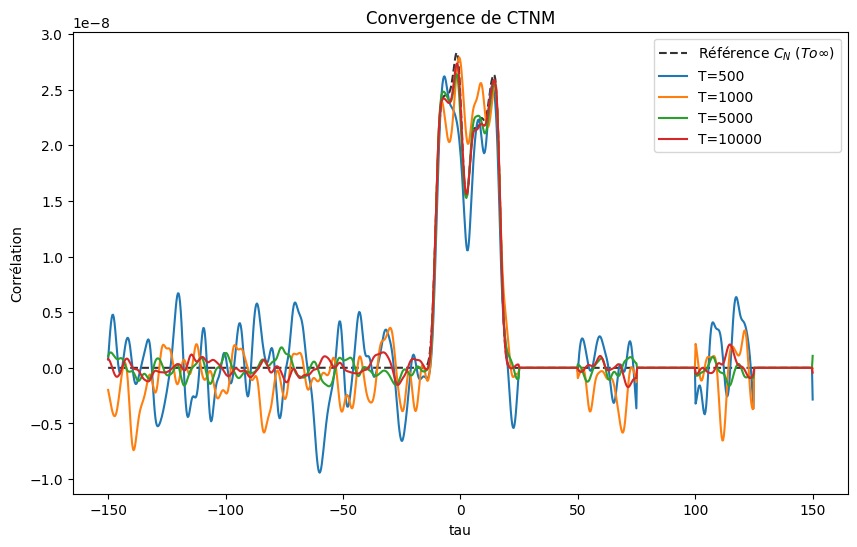

In [110]:
tau_axis = np.linspace(-150, 150, 1000)
plt.figure(figsize=(10,6))

CT = []
for t in tau_axis:
    val = np.real(np.sum(spectrum * np.exp(-1j * omega * t)) * dw)
    CT.append(val)
plt.plot(tau_axis, CT, 'k--', label="Référence $C_N$ ($T \to \infty$)", alpha=0.8)
for T_val in [500,1000,5000,10000]:

    print(f"Calcul pour T = {T_val}...")

    res = compute_CTNM_temporal_final(T_val, receivers[4], receivers[0])

    # correction décalage
    res = res[::-1]

    # 3️⃣ recentrer le pic (optionnel)
    #shift = np.argmax(res) - len(res)//2
    #res = np.roll(res, -shift)

    # 4️⃣ tracer
    plt.plot(tau_axis, res, label=f"T={T_val}")



plt.legend()
plt.xlabel("tau")
plt.ylabel("Corrélation")
plt.title("Convergence de CTNM")
plt.show()

Calcul des corrélations empiriques pour toutes les paires (T=5000, M=20)...
Sommation sur la grille d'imagerie...


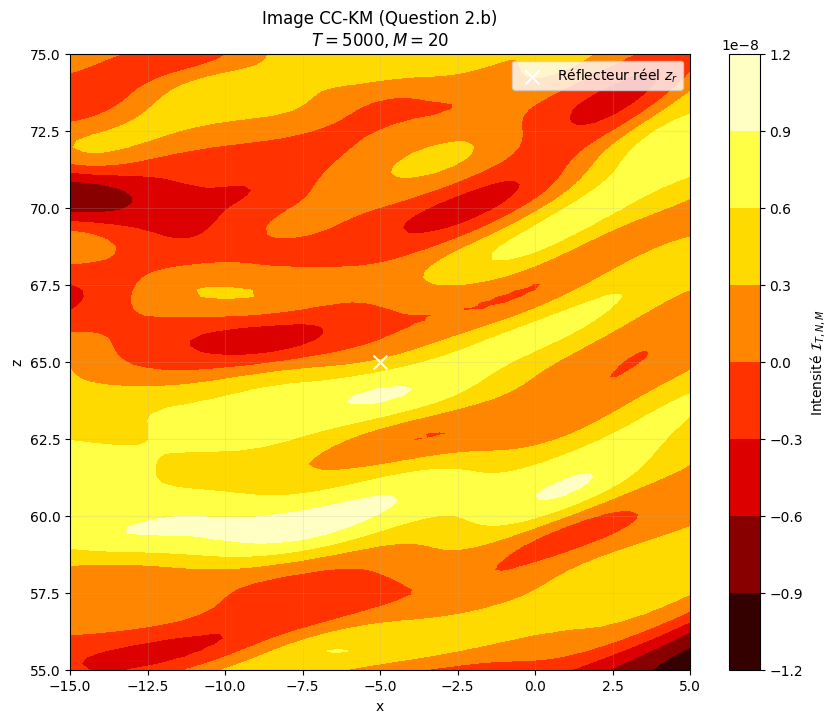

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Paramètres de l'image (Question 2.b) ---
T_img = 5000
M_img = 20    
grid_res = 100

# Fenêtre centrée sur le réflecteur zr = (-5, 0, 65) [cite: 39, 67]
x_grid = np.linspace(-15, 5, grid_res)
z_grid = np.linspace(55, 75, grid_res)
X, Z = np.meshgrid(x_grid, z_grid)

# L'axe tau doit couvrir les temps de trajet possibles (environ 130-150 pour le réflecteur)
# On utilise le même axe que pour vos tracés de la question 2.a
tau_axis = np.linspace(-200, 200, 1000) 

# --- 2. Pré-calcul des corrélations avec votre fonction "final" ---
empirical_interp = {}

print(f"Calcul des corrélations empiriques pour toutes les paires (T={T_img}, M={M_img})...")

for j in range(5):
    for l in range(5):
        # Utilisation de votre fonction compute_CTNM_final
        # Elle renvoie uniquement le vecteur de valeurs c_vals
        c_vals = compute_CTNM(T_img, M_img, receivers[j], receivers[l])
        
        # On crée l'interpolateur pour cette paire spécifique
        empirical_interp[(j, l)] = interp1d(tau_axis, c_vals, kind='linear', fill_value="extrapolate")

# --- 3. Construction de l'image KM (Équation 14) ---
# I(yS) = sum_{j,l} C_T,N,M(|xj-yS| + |yS-xl|, xj, xl) [cite: 78]
KM_image = np.zeros((grid_res, grid_res))

print("Sommation sur la grille d'imagerie...")
for j in range(5):
    xj = receivers[j] # [cite: 28]
    for l in range(5):
        xl = receivers[l]
        f_interp = empirical_interp[(j, l)]
        
        # Calcul vectorisé des distances (c0 = 1) [cite: 39]
        dist_j = np.sqrt((X - xj[0])**2 + (0 - xj[1])**2 + (Z - xj[2])**2)
        dist_l = np.sqrt((X - xl[0])**2 + (0 - xl[1])**2 + (Z - xl[2])**2)
        tau_theory = dist_j + dist_l
        
        # On évalue la corrélation au temps de vol théorique et on l'ajoute à l'image
        KM_image += f_interp(tau_theory)

# --- 4. Affichage des résultats ---
plt.figure(figsize=(10, 8))
# On affiche l'intensité de l'image [cite: 78]
im = plt.contourf(X, Z, KM_image, cmap='hot')
plt.colorbar(im, label='Intensité $\mathcal{I}_{T,N,M}$')

# Marquage du vrai réflecteur pour comparaison [cite: 39]
plt.scatter(-5, 65, color='white', marker='x', s=100, label='Réflecteur réel $z_r$')

plt.title(f"Image CC-KM (Question 2.b)\n$T={T_img}, M={M_img}$")
plt.xlabel("x")
plt.ylabel("z")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Calcul des corrélations différentielles...


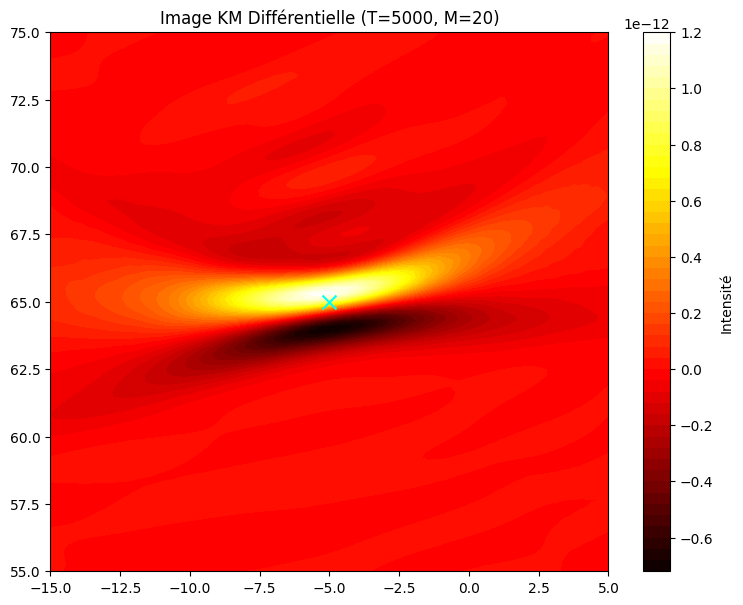

In [113]:
import numpy as np
from scipy.interpolate import interp1d

# --- Paramètres de la grille (Question 2.b) ---
T_img, M_img = 5000, 20
grid_res = 100
x_grid = np.linspace(-15, 5, grid_res) # Fenêtre centrée sur zr [cite: 67]
z_grid = np.linspace(55, 75, grid_res)
X, Z = np.meshgrid(x_grid, z_grid)
tau_axis = np.linspace(-200, 200, 1000)

empirical_interp = {}

print("Calcul des corrélations différentielles...")
for j in range(5):
    for l in range(5):
        # 1. Calcul avec le réflecteur (Sigma = 10^-3) 
        global sigma_r # On s'assure de modifier la variable globale utilisée par G
        sigma_r = 1e-3
        np.random.seed(42) # FIXER LA GRAINE pour avoir le même bruit
        c_full = compute_CTNM(T_img, M_img, receivers[j], receivers[l])
        
        # 2. Calcul sans le réflecteur (Background)
        sigma_r = 0
        np.random.seed(42) # MÊME GRAINE !
        c_bg = compute_CTNM(T_img, M_img, receivers[j], receivers[l])
        
        # 3. Soustraction : on ne garde que la signature du réflecteur
        delta_c = c_full - c_bg
        
        empirical_interp[(j, l)] = interp1d(tau_axis, delta_c, kind='linear', fill_value="extrapolate")

# --- Construction de l'image KM (Eq. 14) ---
KM_image = np.zeros((grid_res, grid_res))

for j in range(5):
    for l in range(5):
        f_int = empirical_interp[(j, l)]
        # Temps de trajet théorique |xj-yS| + |yS-xl| [cite: 78]
        dist_j = np.sqrt((X - receivers[j][0])**2 + (Z - receivers[j][2])**2)
        dist_l = np.sqrt((X - receivers[l][0])**2 + (Z - receivers[l][2])**2)
        KM_image += f_int(dist_j + dist_l)

# --- Affichage ---
plt.figure(figsize=(9, 7))
plt.contourf(X, Z, KM_image, levels=50, cmap='hot')
plt.colorbar(label='Intensité')
plt.scatter(-5, 65, color='cyan', marker='x', s=100, label='Vrai Réflecteur') # 
plt.title(f"Image KM Différentielle (T={T_img}, M={M_img})")
plt.show()

A IGNORER 

Calcul pour T = 1000...


Text(0, 0.5, 'Corrélation')

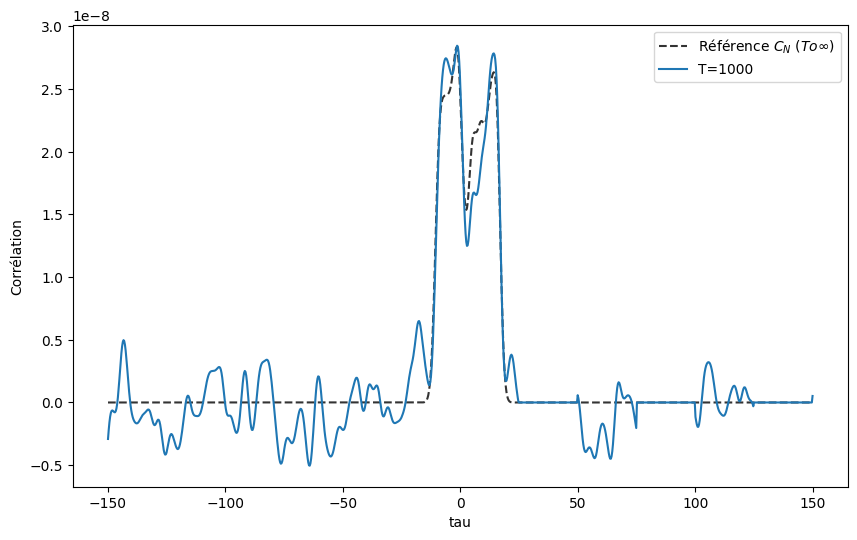

In [109]:
tau_axis = np.linspace(-150, 150, 1000)
plt.figure(figsize=(10,6))

CT = []
for t in tau_axis:
    val = np.real(np.sum(spectrum * np.exp(-1j * omega * t)) * dw)
    CT.append(val)
plt.plot(tau_axis, CT, 'k--', label="Référence $C_N$ ($T \to \infty$)", alpha=0.8)
for T_val in [1000]:

    print(f"Calcul pour T = {T_val}...")

    res = compute_CTNM_temporal_final(T_val, receivers[4], receivers[0])

    # correction décalage
    res = res[::-1]

    # 3️⃣ recentrer le pic (optionnel)
    #shift = np.argmax(res) - len(res)//2
    #res = np.roll(res, -shift)

    # 4️⃣ tracer
    plt.plot(tau_axis, res, label=f"T={T_val}")



plt.legend()
plt.xlabel("tau")
plt.ylabel("Corrélation")

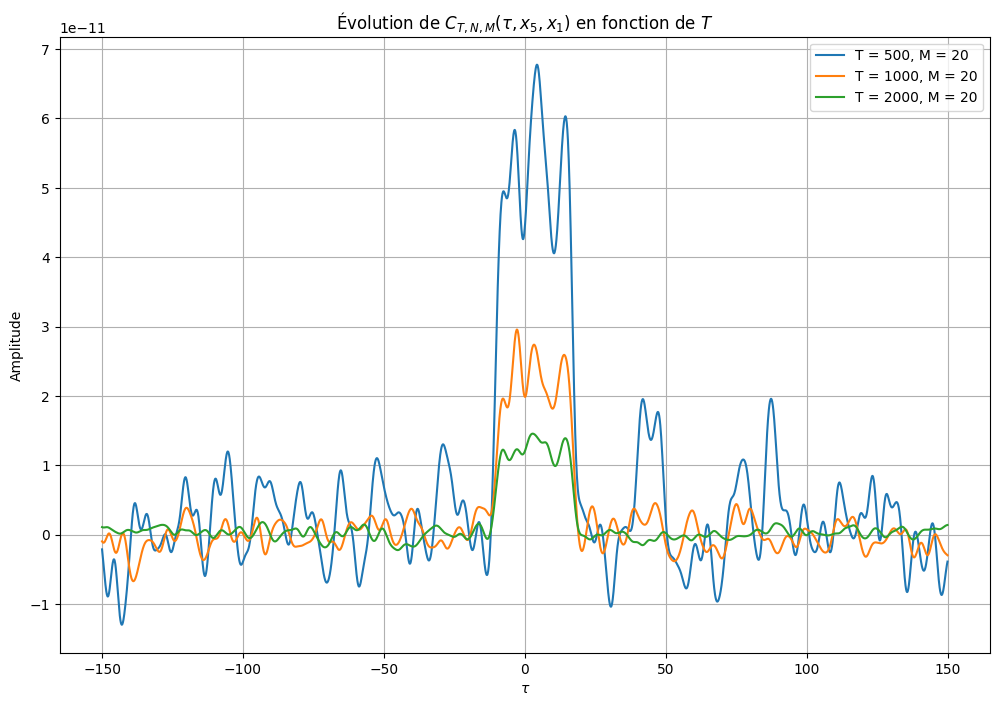

In [ ]:
def compute_CTNM_average(T, M, x_j, x_l, noise_sources, zr, sigma_r, dt=0.1):
    """
    Calcule la moyenne de M corrélations croisées empiriques pour un temps T.
    """
    accumulated_corr = None
    tau = None
    
    for m in range(M):
        # On génère une nouvelle réalisation du bruit pour chaque fenêtre m
        current_tau, current_C = compute_CTN(T, x_j, x_l, y, zr, sigma_r, dt)
        
        if accumulated_corr is None:
            accumulated_corr = current_C
            tau = current_tau
        else:
            accumulated_corr += current_C
            
    return tau, accumulated_corr / M

# --- Question 2.a : Comparaison pour différents T ---
M = 20  # Nombre de fenêtres pour la stabilité
T_values = [500, 1000, 2000]
x5 = receivers[4]
x1 = receivers[0]

plt.figure(figsize=(12, 8))

for T_val in T_values:
    tau_avg, C_avg = compute_CTNM_average(T_val, M, x5, x1, y, zr, sigma_r)
    
    # On restreint l'affichage à [-150, 150] comme demandé
    mask = (tau_avg >= -150) & (tau_avg <= 150)
    plt.plot(tau_avg[mask], C_avg[mask], label=f'T = {T_val}, M = {M}')

plt.title(r"Évolution de $C_{T,N,M}(\tau, x_5, x_1)$ en fonction de $T$")
plt.xlabel(r"$\tau$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

Calcul pour T=500...
Calcul pour T=1000...
Calcul pour T=4000...
Calcul pour T=10000...


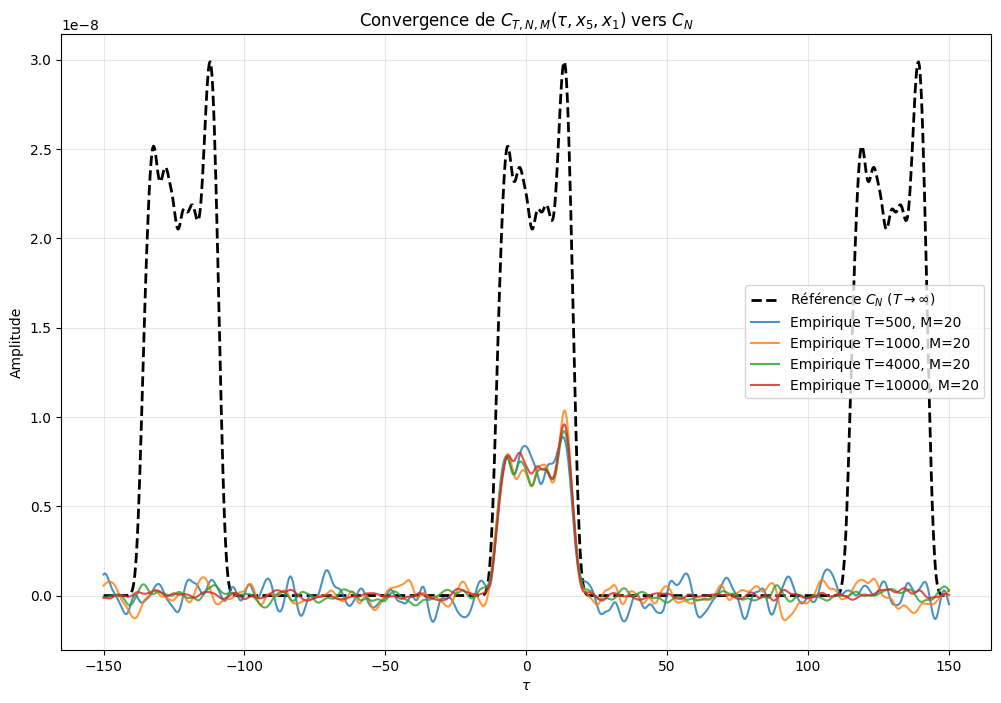

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres et Fonctions de base ---
c0 = 1.0
sigma_r = 1e-3
zr = np.array([-5, 0, 65])
receivers = np.array([[-30 + 7.5 * (j - 1), 0, 100] for j in range(1, 6)])
N_src = 200

# Génération des sources de bruit (K)
noise_sources = np.zeros((N_src, 3))
noise_sources[:, 0] = np.random.uniform(-50, 50, N_src)
noise_sources[:, 1] = np.random.uniform(-10, 10, N_src)
noise_sources[:, 2] = np.random.uniform(185, 200, N_src)

def F_hat(w):
    return np.exp(-w**2) # [cite: 13]

def G0(w, x, y):
    dist = np.linalg.norm(x - y, axis=-1)
    dist = np.atleast_1d(dist)
    # On gère w comme un vecteur pour la rapidité
    return (1 / (4 * np.pi * dist)) * np.exp(1j * w[:, None] * dist / c0)

def G_born(w, x, sources):
    g0_xs = G0(w, x, sources)
    g0_xzr = G0(w, x, zr)
    g0_zrs = G0(w, zr, sources)
    return g0_xs + sigma_r * (w**2)[:, None] * g0_xzr * g0_zrs # [cite: 38]

# --- 2. Calcul de la Référence C_N (Théorique T -> inf) ---
dw = 0.05
omega = np.arange(-10, 10, dw)
tau_axis = np.linspace(-150, 150, 1000)

def compute_CN_ref(xj, xl):
    Gj = G_born(omega, xj, noise_sources)
    Gl = G_born(omega, xl, noise_sources)
    # Eq (7): Moyenne statistique sur les sources
    spectrum = F_hat(omega) * np.sum(np.conj(Gj) * Gl, axis=1) / (2 * np.pi * N_src) # [cite: 46]
    
    cn_tau = []
    for t in tau_axis:
        val = np.real(np.sum(spectrum * np.exp(-1j * omega * t)) * dw)
        cn_tau.append(val)
    return np.array(cn_tau)

# --- 3. Simulation de C_T,N,M (Approche Spectrale Rapide) ---
def compute_CTNM_fast(T, M, xj, xl):
    # Pour un temps T, la résolution fréquentielle est 2*pi/T
    dw_T = 2 * np.pi / T
    omega_T = np.arange(-10, 10, dw_T)
    
    Gj = G_born(omega_T, xj, noise_sources)
    Gl = G_born(omega_T, xl, noise_sources)
    
    C_acc = np.zeros(len(tau_axis))
    
    for m in range(M):
        # Génération du bruit aléatoire pour chaque source s
        # n_s(w) a une variance proportionnelle à F_hat(w) * T
        noise_f = (np.random.normal(0, 1, (len(omega_T), N_src)) + 
                   1j * np.random.normal(0, 1, (len(omega_T), N_src)))
        noise_f *= np.sqrt(F_hat(omega_T) * T / (2 * np.pi))[:, np.newaxis]
        
        # Signaux reçus (Eq 41)
        u_j = np.sum(Gj * noise_f, axis=1) / np.sqrt(N_src)
        u_l = np.sum(Gl * noise_f, axis=1) / np.sqrt(N_src)
        
        # Corrélation empirique dans le domaine fréquentiel
        # C_T ~ conj(u_j) * u_l / T
        spectrum_emp = (np.conj(u_j) * u_l) / (2 * np.pi * T)
        
        # Reconstruction temporelle pour tau_axis
        for i, t in enumerate(tau_axis):
            C_acc[i] += np.real(np.sum(spectrum_emp * np.exp(-1j * omega_T * t)) * dw_T)
            
    return C_acc / M # [cite: 76]

# --- 4. Tracé des résultats ---
xj, xl = receivers[4], receivers[0] # x5 et x1
T_list = [500, 1000, 4000, 10000]
M = 20

plt.figure(figsize=(12, 8))

# Référence
ref = compute_CN_ref(xj, xl)
plt.plot(tau_axis, ref, 'k--', label="Référence $C_N$ ($T \\to \\infty$)", lw=2)

# Empirique pour chaque T
for T in T_list:
    print(f"Calcul pour T={T}...")
    c_emp = compute_CTNM_fast(T, M, xj, xl)
    plt.plot(tau_axis, c_emp, label=f"Empirique T={T}, M={M}", alpha=0.8)

plt.title(r"Convergence de $C_{T,N,M}(\tau, x_5, x_1)$ vers $C_N$")
plt.xlabel(r"$\tau$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

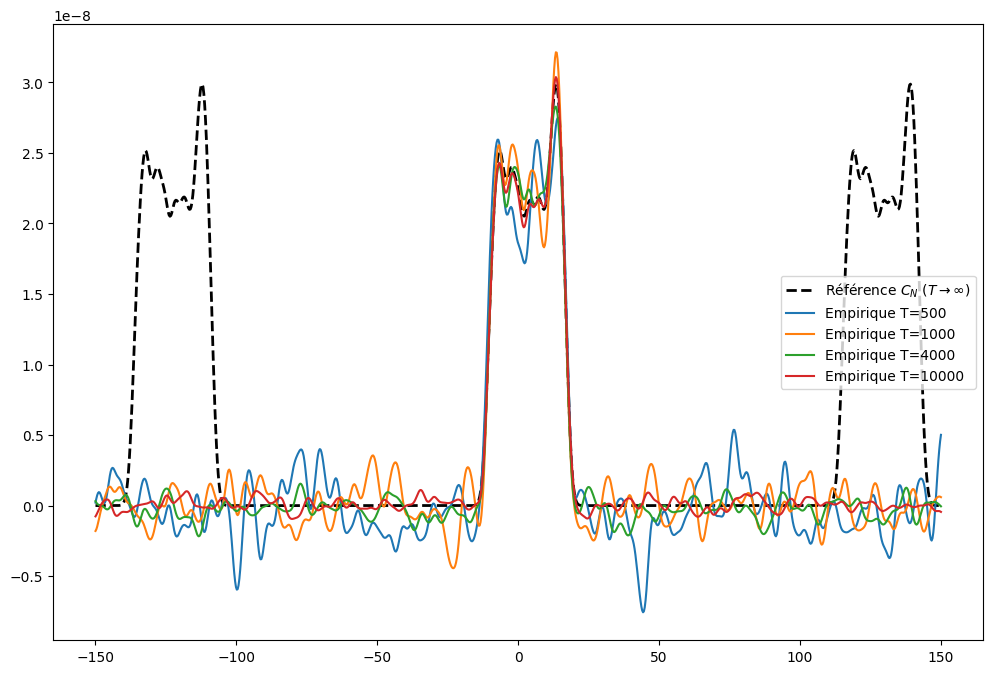

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres inchangés ---
# (Assurez-vous que dw, omega, et receivers sont définis comme précédemment)

def compute_CTNM_final(T, M, xj, xl):
    # La résolution fréquentielle imposée par la fenêtre temporelle T
    dw_T = 2 * np.pi / T 
    # On définit omega sur la plage supportée par F_hat
    omega_T = np.arange(-10, 10, dw_T)
    
    Gj = G_born(omega_T, xj, noise_sources)
    Gl = G_born(omega_T, xl, noise_sources)
    
    # Pré-calcul des constantes de normalisation
    # n_s(w) est défini tel que sa variance est F_hat * T (en discret)
    # Le facteur 1/(2*pi) vient de la définition de u(t)
    norm_factor = 1 / (2 * np.pi)
    
    C_acc = np.zeros(len(tau_axis))
    
    for m in range(M):
        # Génération du bruit n_s(w)
        noise_f = (np.random.normal(0, 1, (len(omega_T), N_src)) + 
                   1j * np.random.normal(0, 1, (len(omega_T), N_src))) / np.sqrt(2)
        
        # On applique la densité spectrale de puissance F(w)
        # La multiplication par sqrt(T) assure la cohérence avec l'intégrale temporelle
        noise_f *= np.sqrt(F_hat(omega_T) * T)[:, np.newaxis]
        
        # Spectres reçus u_hat (Eq. 41 modifiée pour la discrétisation)
        u_j = np.sum(Gj * noise_f, axis=1) / np.sqrt(N_src)
        u_l = np.sum(Gl * noise_f, axis=1) / np.sqrt(N_src)
        
        # La corrélation empirique C_T ~ (1/T) * u_j* * u_l
        # On inclut le (1/2pi)^2 de la transformée de Fourier
        spectrum_emp = (np.conj(u_j) * u_l) / (T * (2 * np.pi))
        
        # Reconstruction temporelle via l'intégrale (somme de Riemann)
        for i, t in enumerate(tau_axis):
            # Le dw_T final vient de l'intégrale d_omega
            C_acc[i] += np.real(np.sum(spectrum_emp * np.exp(-1j * omega_T * t)) * dw_T)
            
    return C_acc / M

# --- Visualisation ---
plt.figure(figsize=(12, 8))
# ... (Tracé de votre référence cn_tau) ...

plt.plot(tau_axis, ref, 'k--', label="Référence $C_N$ ($T \\to \\infty$)", lw=2)


for T in [500, 1000, 4000, 10000]:
    c_emp = compute_CTNM_final(T, M, receivers[4], receivers[0])
    plt.plot(tau_axis, c_emp, label=f"Empirique T={T}")

plt.legend()
plt.show()

Calcul des corrélations empiriques pour toutes les paires (T=10000, M=20)...
Sommation sur la grille d'imagerie...


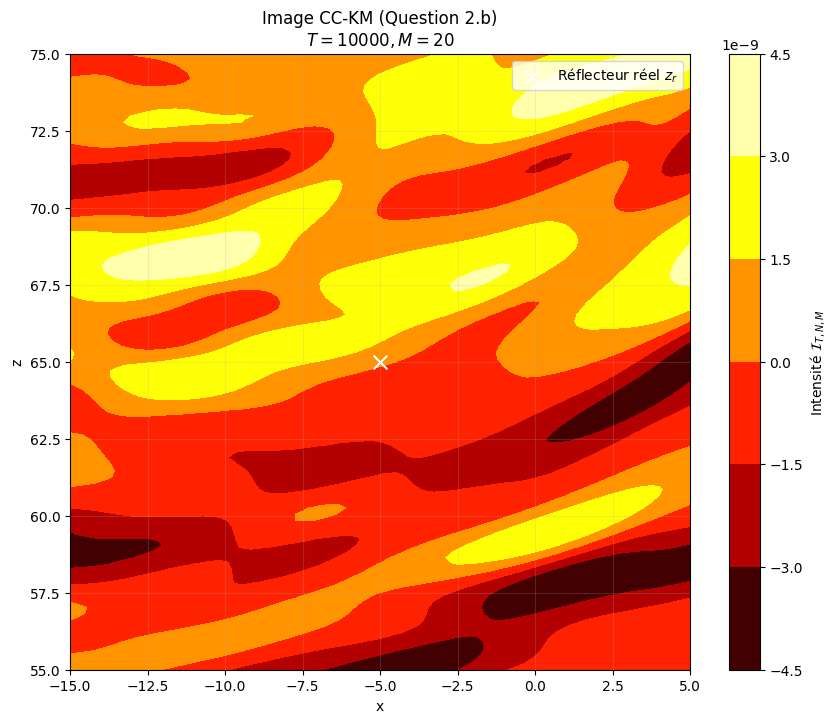

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Paramètres de l'image (Question 2.b) ---
T_img = 10000
M_img = 20    
grid_res = 100

# Fenêtre centrée sur le réflecteur zr = (-5, 0, 65) [cite: 39, 67]
x_grid = np.linspace(-15, 5, grid_res)
z_grid = np.linspace(55, 75, grid_res)
X, Z = np.meshgrid(x_grid, z_grid)

# L'axe tau doit couvrir les temps de trajet possibles (environ 130-150 pour le réflecteur)
# On utilise le même axe que pour vos tracés de la question 2.a
tau_axis = np.linspace(-200, 200, 1000) 

# --- 2. Pré-calcul des corrélations avec votre fonction "final" ---
empirical_interp = {}

print(f"Calcul des corrélations empiriques pour toutes les paires (T={T_img}, M={M_img})...")

for j in range(5):
    for l in range(5):
        # Utilisation de votre fonction compute_CTNM_final
        # Elle renvoie uniquement le vecteur de valeurs c_vals
        c_vals = compute_CTNM_final(T_img, M_img, receivers[j], receivers[l])
        
        # On crée l'interpolateur pour cette paire spécifique
        empirical_interp[(j, l)] = interp1d(tau_axis, c_vals, kind='linear', fill_value="extrapolate")

# --- 3. Construction de l'image KM (Équation 14) ---
# I(yS) = sum_{j,l} C_T,N,M(|xj-yS| + |yS-xl|, xj, xl) [cite: 78]
KM_image = np.zeros((grid_res, grid_res))

print("Sommation sur la grille d'imagerie...")
for j in range(5):
    xj = receivers[j] # [cite: 28]
    for l in range(5):
        xl = receivers[l]
        f_interp = empirical_interp[(j, l)]
        
        # Calcul vectorisé des distances (c0 = 1) [cite: 39]
        dist_j = np.sqrt((X - xj[0])**2 + (0 - xj[1])**2 + (Z - xj[2])**2)
        dist_l = np.sqrt((X - xl[0])**2 + (0 - xl[1])**2 + (Z - xl[2])**2)
        tau_theory = dist_j + dist_l
        
        # On évalue la corrélation au temps de vol théorique et on l'ajoute à l'image
        KM_image += f_interp(tau_theory)

# --- 4. Affichage des résultats ---
plt.figure(figsize=(10, 8))
# On affiche l'intensité de l'image [cite: 78]
im = plt.contourf(X, Z, KM_image, cmap='hot')
plt.colorbar(im, label='Intensité $\mathcal{I}_{T,N,M}$')

# Marquage du vrai réflecteur pour comparaison [cite: 39]
plt.scatter(-5, 65, color='white', marker='x', s=100, label='Réflecteur réel $z_r$')

plt.title(f"Image CC-KM (Question 2.b)\n$T={T_img}, M={M_img}$")
plt.xlabel("x")
plt.ylabel("z")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Calcul des corrélations différentielles (T=1000, M=20)...
Sommation sur la grille d'imagerie...


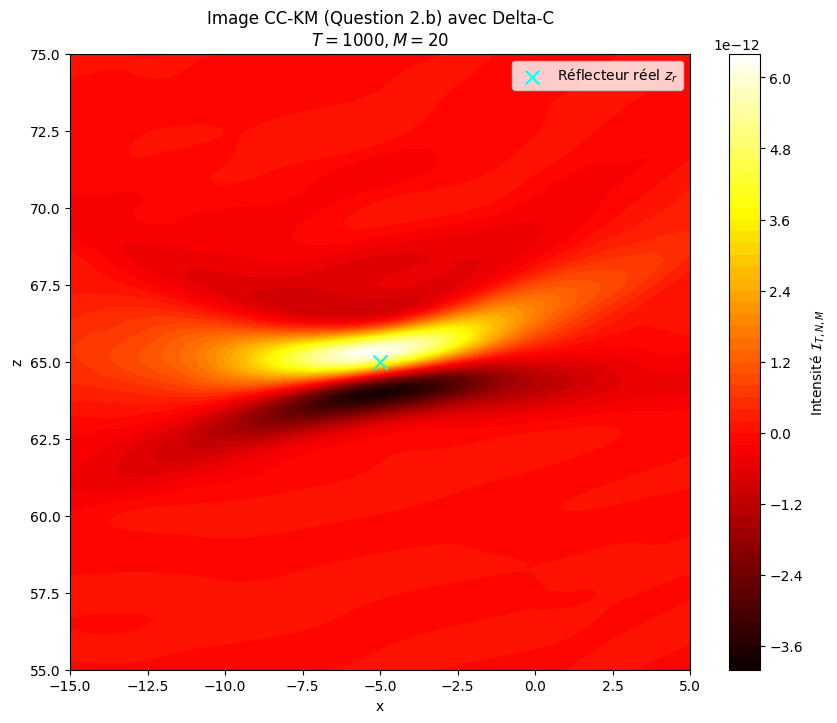

In [ ]:
T_img=1000
print(f"Calcul des corrélations différentielles (T={T_img}, M={M_img})...")

for j in range(5):
    for l in range(j, 5): # On optimise en calculant j <= l
        # Ici on simule u_full et u_background pour soustraire
        # u_full : avec réflecteur (Born Approximation [cite: 38])
        # u_background : sans réflecteur
        c_vals = compute_delta_CTNM_final(T_img, M_img, j, l)
        
        # On crée l'interpolateur
        empirical_interp[(j, l)] = interp1d(tau_axis, c_vals, kind='linear', fill_value=0, bounds_error=False)

# --- 2. Construction de l'image KM (Équation 14) ---
grid_res = 100
x_grid = np.linspace(-15, 5, grid_res)
z_grid = np.linspace(55, 75, grid_res)
X, Z = np.meshgrid(x_grid, z_grid)
KM_image = np.zeros((grid_res, grid_res))

print("Sommation sur la grille d'imagerie...")
for j in range(5):
    xj = receivers[j]
    for l in range(5):
        # Gestion de la symétrie j/l
        pair = (j, l) if j <= l else (l, j)
        f_interp = empirical_interp[pair]
        
        dist_j = np.sqrt((X - xj[0])**2 + (0 - xj[1])**2 + (Z - xj[2])**2)
        dist_l = np.sqrt((X - receivers[l][0])**2 + (0 - receivers[l][1])**2 + (Z - receivers[l][2])**2)
        
        # Si j > l, on cherche C(-tau, xl, xj) car C(tau, xj, xl) = C(-tau, xl, xj)
        tau_theory = (dist_j + dist_l) if j <= l else -(dist_j + dist_l)
        
        KM_image += f_interp(tau_theory)

# --- 3. Affichage ---
plt.figure(figsize=(10, 8))
im = plt.contourf(X, Z, KM_image, levels=50, cmap='hot')
plt.colorbar(im, label='Intensité $\mathcal{I}_{T,N,M}$')
plt.scatter(-5, 65, color='cyan', marker='x', s=100, label='Réflecteur réel $z_r$')
plt.title(f"Image CC-KM (Question 2.b) avec Delta-C\n$T={T_img}, M={M_img}$")
plt.xlabel("x"); plt.ylabel("z")
plt.legend(); plt.show()

In [ ]:
def compute_delta_CTNM_final(T, M, j, l):
    """
    Calcule la corrélation différentielle en utilisant ta fonction G.
    """
    dw_T = 2 * np.pi / T
    w_T = np.arange(0.1, 5, dw_T) # Éviter w=0 pour la division [cite: 13]
    
    # Récepteurs j et l [cite: 28]
    xj = receivers[j]
    xl = receivers[l]
    
    # 1. Pré-calcul des fonctions de Green avec TA fonction G [cite: 38]
    # G_full utilise ton sigma_r actuel
    G_f_j = G(w_T, xj, noise_sources) 
    G_f_l = G(w_T, xl, noise_sources)
    
    # G_0 (Background) : on refait le calcul avec sigma_r = 0 pour soustraire le fond
    # On peut aussi appeler ta fonction G0(w, x, y) directement si tu l'as définie
    G_0_j = G0(w_T, xj, noise_sources)
    G_0_l = G0(w_T, xl, noise_sources)
    
    delta_C_sum = np.zeros(len(tau_axis))

    for m in range(M):
        # Génération du bruit blanc Gaussien filtré par F_hat [cite: 13, 25]
        noise_f = (np.random.normal(0, 1, (len(w_T), N_src)) + 
                   1j * np.random.normal(0, 1, (len(w_T), N_src))) * np.sqrt(F(w_T))[:, np.newaxis]
        
        # Spectres reçus (Eq. 41) [cite: 41]
        u_f_j = np.sum(G_f_j * noise_f, axis=1) / np.sqrt(N_src)
        u_f_l = np.sum(G_f_l * noise_f, axis=1) / np.sqrt(N_src)
        
        u_0_j = np.sum(G_0_j * noise_f, axis=1) / np.sqrt(N_src)
        u_0_l = np.sum(G_0_l * noise_f, axis=1) / np.sqrt(N_src)
        
        # Corrélation différentielle (Soustraction du trajet direct)
        spec_diff = (np.conj(u_f_j) * u_f_l) - (np.conj(u_0_j) * u_0_l)
        
        # Reconstruction temporelle [cite: 46]
        for i, t in enumerate(tau_axis):
            delta_C_sum[i] += np.real(np.sum(spec_diff * np.exp(-1j * w_T * t)) * dw_T)
            
    return delta_C_sum / M

Calcul des corrélations différentielles...


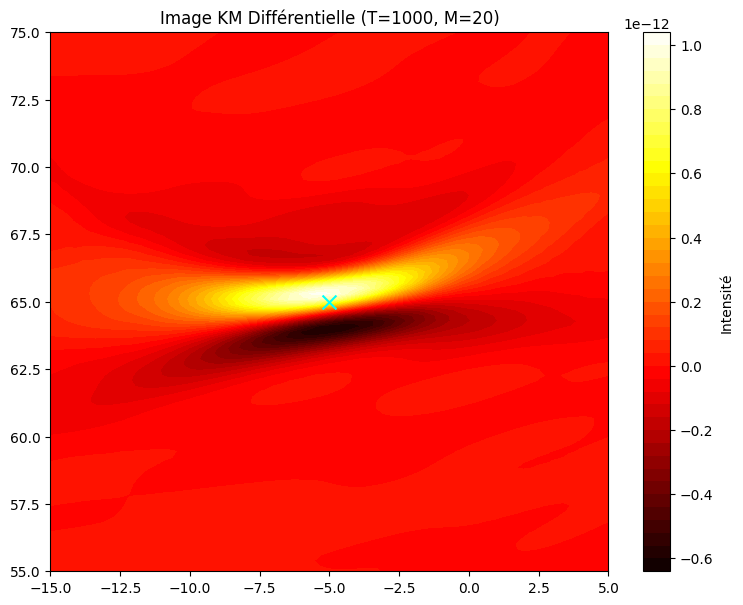

In [ ]:
import numpy as np
from scipy.interpolate import interp1d

# --- Paramètres de la grille (Question 2.b) ---
T_img, M_img = 1000, 20
grid_res = 100
x_grid = np.linspace(-15, 5, grid_res) # Fenêtre centrée sur zr [cite: 67]
z_grid = np.linspace(55, 75, grid_res)
X, Z = np.meshgrid(x_grid, z_grid)
tau_axis = np.linspace(-200, 200, 1000)

empirical_interp = {}

print("Calcul des corrélations différentielles...")
for j in range(5):
    for l in range(5):
        # 1. Calcul avec le réflecteur (Sigma = 10^-3) 
        global sigma_r # On s'assure de modifier la variable globale utilisée par G
        sigma_r = 1e-3
        np.random.seed(42) # FIXER LA GRAINE pour avoir le même bruit
        c_full = compute_CTNM_final(T_img, M_img, receivers[j], receivers[l])
        
        # 2. Calcul sans le réflecteur (Background)
        sigma_r = 0
        np.random.seed(42) # MÊME GRAINE !
        c_bg = compute_CTNM_final(T_img, M_img, receivers[j], receivers[l])
        
        # 3. Soustraction : on ne garde que la signature du réflecteur
        delta_c = c_full - c_bg
        
        empirical_interp[(j, l)] = interp1d(tau_axis, delta_c, kind='linear', fill_value="extrapolate")

# --- Construction de l'image KM (Eq. 14) ---
KM_image = np.zeros((grid_res, grid_res))

for j in range(5):
    for l in range(5):
        f_int = empirical_interp[(j, l)]
        # Temps de trajet théorique |xj-yS| + |yS-xl| [cite: 78]
        dist_j = np.sqrt((X - receivers[j][0])**2 + (Z - receivers[j][2])**2)
        dist_l = np.sqrt((X - receivers[l][0])**2 + (Z - receivers[l][2])**2)
        KM_image += f_int(dist_j + dist_l)

# --- Affichage ---
plt.figure(figsize=(9, 7))
plt.contourf(X, Z, KM_image, levels=50, cmap='hot')
plt.colorbar(label='Intensité')
plt.scatter(-5, 65, color='cyan', marker='x', s=100, label='Vrai Réflecteur') # 
plt.title(f"Image KM Différentielle (T={T_img}, M={M_img})")
plt.show()

Calcul des corrélations...
Construction de l'image...


C:\Users\athee\AppData\Local\Temp\ipykernel_84168\3300691978.py:49: UserWarning: The following kwargs were not used by contour: 'shading'
  plt.contourf(X, Z, I_KM, shading='gouraud', cmap='hot')


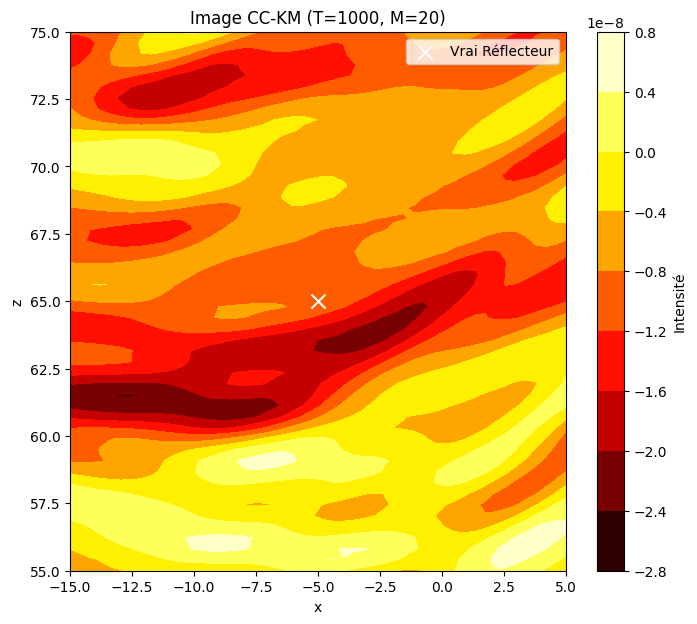

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# Temps d'enregistrement et nombre de fenêtres [cite: 55, 57]
T_img = 1000
M_img = 20
# Axe tau couvrant les temps de trajet aller-retour possibles
tau_axis = np.linspace(0, 200, 500) 

# --- 2. Calcul des corrélations ---
# On calcule la matrice (5, 5, len(tau)) contenant C_T,N,M pour chaque paire (j, l)
# Utilisez votre fonction compute_CTNM_final adaptée pour renvoyer juste les valeurs
print("Calcul des corrélations...")
C_matrix = np.zeros((5, 5, len(tau_axis)))
for j in range(5):
    for l in range(5):
        # On suppose que compute_CTNM_final renvoie uniquement le vecteur de valeurs
        C_matrix[j, l, :] = compute_CTNM_final(T_img, M_img, receivers[j], receivers[l])

# --- 3. Construction de l'image KM ---
I_KM = np.zeros(X.shape)

print("Construction de l'image...")
for j in range(5):
    xj = receivers[j]
    for l in range(5):
        xl = receivers[l]
        
        # Interpolation pour la paire (j, l)
        f_interp = interp1d(tau_axis, C_matrix[j, l, :], kind='linear', fill_value="extrapolate")
        
        # Temps de vol théorique avec c0 = 1 (Eq 14) [cite: 62, 12]
        dist_j = np.sqrt((X - xj[0])**2 + (0 - xj[1])**2 + (Z - xj[2])**2)
        dist_l = np.sqrt((X - xl[0])**2 + (0 - xl[1])**2 + (Z - xl[2])**2)
        tau_theory = dist_j + dist_l
        
        # Accumulation dans l'image
        I_KM += f_interp(tau_theory)

# --- 4. Affichage ---
plt.figure(figsize=(8, 7))
plt.contourf(X, Z, I_KM, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensité')
plt.scatter(-5, 65, color='white', marker='x', s=100, label='Vrai Réflecteur')
plt.title(f"Image CC-KM (T={T_img}, M={M_img})")
plt.xlabel("x")
plt.ylabel("z")
plt.legend()
plt.show()